In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_data
from src.pairs.selection import test_all_pairs
from src.pairs.spread import compute_pair_spread
from src.models.ou_process import calibrate_ou, half_life

sns.set_theme(style="whitegrid")
prices, log_returns = load_data(config_path="../config/params.yaml")
pairs = test_all_pairs(prices, pvalue_threshold=0.05)

Dropped 2 tickers (insufficient history): {'WBA', 'DOW'}


In [3]:
records = []
spreads = {}

for _, row in pairs.iterrows():
    a, b = row["ticker_a"], row["ticker_b"]
    pair_df = compute_pair_spread(prices[a], prices[b])
    spread = pair_df["spread"].dropna()

    params = calibrate_ou(spread.values)
    hl = half_life(params.theta)

    records.append({
        "pair": f"{a}/{b}",
        "mu": round(params.mu, 4),
        "theta": round(params.theta, 4),
        "sigma": round(params.sigma, 4),
        "half_life_days": round(hl, 1),
        "coint_pvalue": row["coint_pvalue"],
    })
    spreads[f"{a}/{b}"] = pair_df

summary = pd.DataFrame(records).sort_values("half_life_days").reset_index(drop=True)
summary

,pair,mu,theta,sigma,half_life_days,coint_pvalue
0,AVGO/BKNG,0.0126,1.5585,0.4873,0.4,0.000539
1,JNJ/TMO,-0.0833,0.6864,1.5473,1.0,0.004640
2,CL/MA,-0.0428,0.6813,0.8624,1.0,0.002409
3,AIG/GD,-0.0017,0.4771,0.6232,1.5,0.003360
4,MA/V,0.1645,0.2894,2.3495,2.4,0.000011
5,MO/RTX,-0.0096,0.2699,0.5211,2.6,0.003145
6,ACN/HD,0.0992,0.1953,3.7677,3.5,0.001258
7,HON/TXN,-0.0620,0.1968,2.5387,3.5,0.002319
8,EMR/GOOG,-0.1265,0.1855,1.4032,3.7,0.002515
9,AMZN/CRM,0.1279,0.1824,2.7020,3.8,0.003198


In [4]:
tradeable = summary[(summary["theta"] > 0) & (summary["half_life_days"] < 100)].copy()
print(f"{len(tradeable)} of {len(summary)} pairs have positive theta and half-life < 100 days")
tradeable

20 of 20 pairs have positive theta and half-life < 100 days


,pair,mu,theta,sigma,half_life_days,coint_pvalue
0,AVGO/BKNG,0.0126,1.5585,0.4873,0.4,0.000539
1,JNJ/TMO,-0.0833,0.6864,1.5473,1.0,0.004640
2,CL/MA,-0.0428,0.6813,0.8624,1.0,0.002409
3,AIG/GD,-0.0017,0.4771,0.6232,1.5,0.003360
4,MA/V,0.1645,0.2894,2.3495,2.4,0.000011
5,MO/RTX,-0.0096,0.2699,0.5211,2.6,0.003145
6,ACN/HD,0.0992,0.1953,3.7677,3.5,0.001258
7,HON/TXN,-0.0620,0.1968,2.5387,3.5,0.002319
8,EMR/GOOG,-0.1265,0.1855,1.4032,3.7,0.002515
9,AMZN/CRM,0.1279,0.1824,2.7020,3.8,0.003198


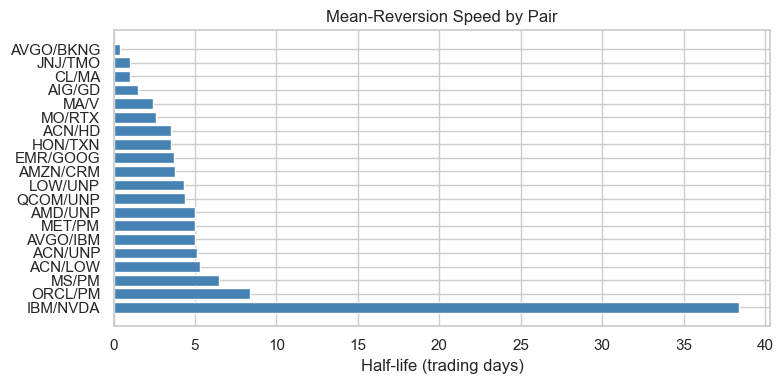

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(tradeable["pair"], tradeable["half_life_days"], color="steelblue")
ax.set_xlabel("Half-life (trading days)")
ax.set_title("Mean-Reversion Speed by Pair")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

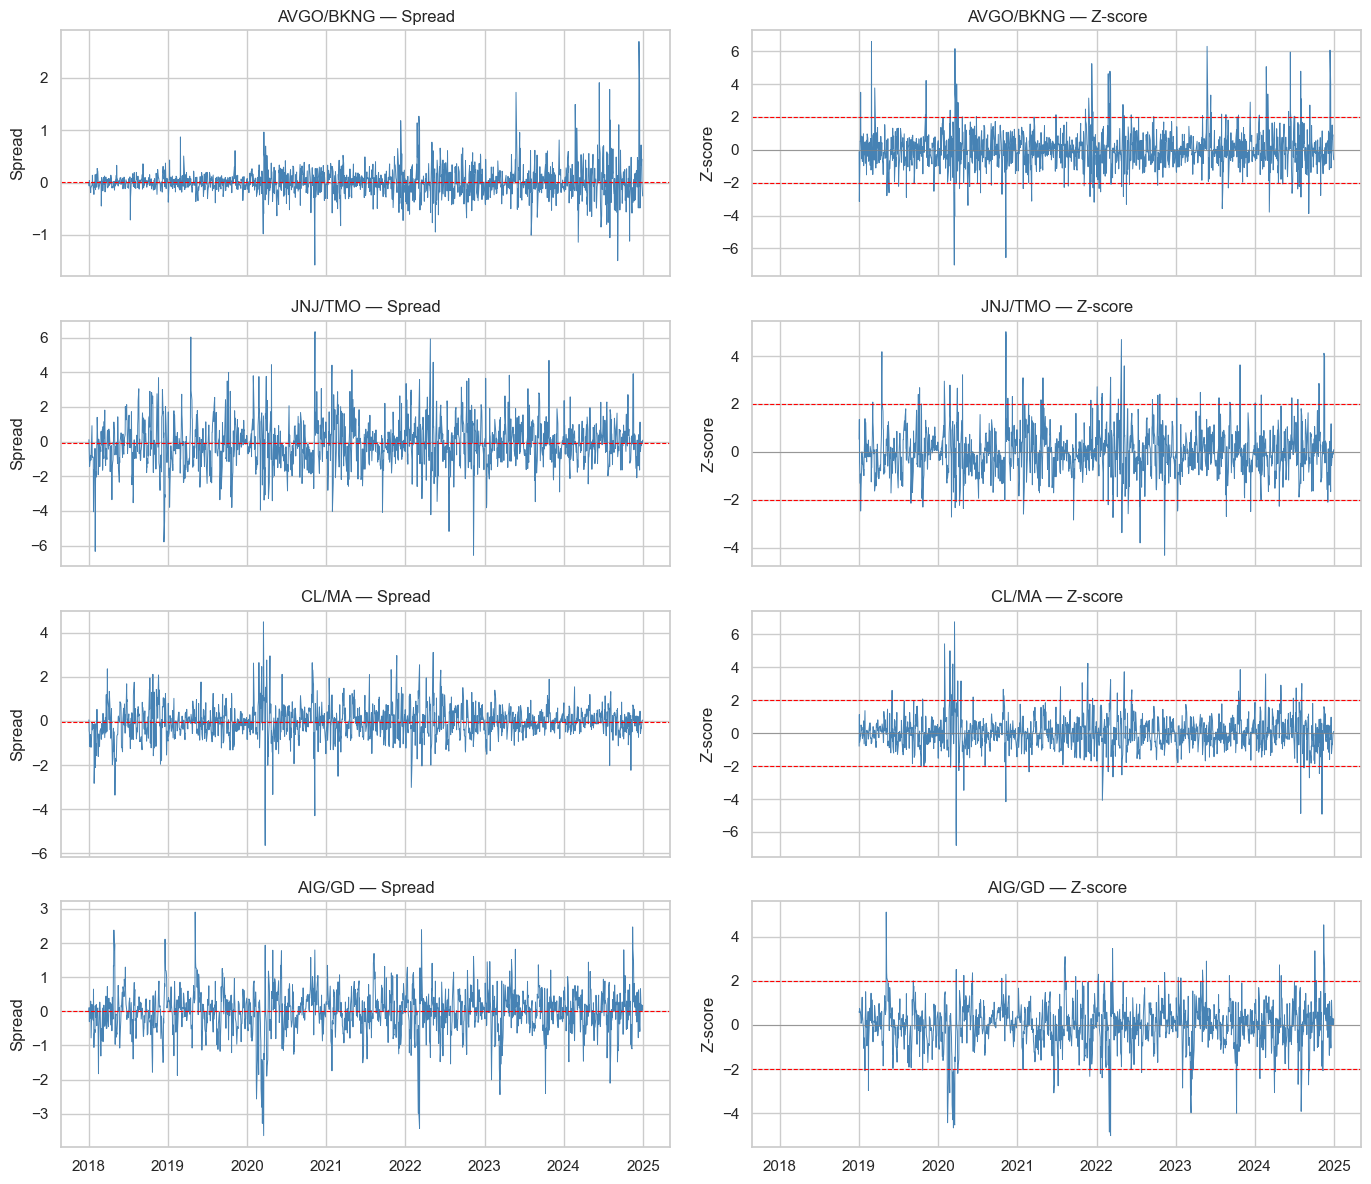

In [6]:
top_pairs = tradeable.head(4)["pair"].tolist()

fig, axes = plt.subplots(len(top_pairs), 2, figsize=(14, 3 * len(top_pairs)), sharex=True)

for i, pair_name in enumerate(top_pairs):
    df = spreads[pair_name]

    # spread panel
    axes[i, 0].plot(df.index, df["spread"], linewidth=0.7, color="steelblue")
    axes[i, 0].axhline(df["spread"].mean(), color="red", ls="--", linewidth=0.8)
    axes[i, 0].set_ylabel("Spread")
    axes[i, 0].set_title(f"{pair_name} — Spread")

    # z-score panel
    axes[i, 1].plot(df.index, df["zscore"], linewidth=0.7, color="steelblue")
    axes[i, 1].axhline(0, color="grey", ls="-", linewidth=0.5)
    for z in [2, -2]:
        axes[i, 1].axhline(z, color="red", ls="--", linewidth=0.8)
    axes[i, 1].set_ylabel("Z-score")
    axes[i, 1].set_title(f"{pair_name} — Z-score")

plt.tight_layout()
plt.show()

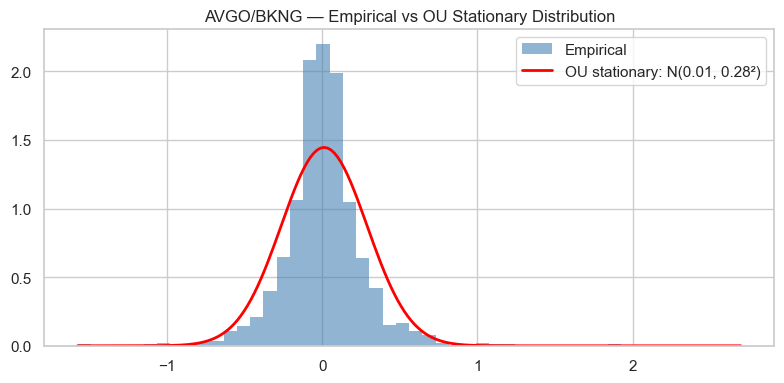

In [7]:
best = tradeable.iloc[0]
pair_name = best["pair"]
spread = spreads[pair_name]["spread"].dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(spread, bins=50, density=True, alpha=0.6, color="steelblue", edgecolor="none",
        label="Empirical")

# OU stationary distribution: N(mu, sigma^2 / (2*theta))
from scipy.stats import norm
ou_std = best["sigma"] / np.sqrt(2 * best["theta"])
x = np.linspace(spread.min(), spread.max(), 200)
ax.plot(x, norm.pdf(x, best["mu"], ou_std), color="red", linewidth=2,
        label=f'OU stationary: N({best["mu"]:.2f}, {ou_std:.2f}²)')

ax.set_title(f"{pair_name} — Empirical vs OU Stationary Distribution")
ax.legend()
plt.tight_layout()
plt.show()